# Análise de Estacionariedade do Consumo de Energia Elétrica

## Lucas Eduardo Silva Braga


## 1. Importação das bibliotecas e download dos dados

In [1]:
from StationarityAnalyzer import StationarityAnalyzer

# Criar uma instância (baixa o dataset automaticamente)
analyzer = StationarityAnalyzer()

# Visualizar as casas disponíveis
print(analyzer.get_homes())

Baixando dataset do Kaggle...
Dataset baixado.


c:\Users\lucas\repositorios\mestrado_luedsbr\stocastic\StationarityAnalyzer.py:57: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = self.df_raw.groupby([pd.Grouper(freq='H'), 'home_id'])['power_watt'].sum().reset_index()
c:\Users\lucas\repositorios\mestrado_luedsbr\stocastic\StationarityAnalyzer.py:50: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.series[home] = ts.asfreq('H').dropna()


[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


# 2. Análise de séires de consumo de energia horário

Foi feita uma análise das séries temporais de consumo de energia elétrica em que se utilizou um dataset simulado com dados de 10 residências ao longo de 2022, registrados a cada 15 minutos.

### Objetivos:
- Realizar uma análise descritiva completa das séries de consumo horário.
- Compreender o que é um processo estocástico e sua classificação quanto à estacionariedade.
- Verificar a estacionariedade no sentido amplo (WSS) utilizando testes estatísticos e gráficos.

O dataset original tem medidas a cada 15 minutos. Para uma análise de séries temporais, é comum agregar em intervalos maiores (hora, dia) para reduzir ruído e facilitar a interpretação.

### Cálculo da energia horária (kWh)
Cada registro fornece a potência instantânea em watts. A energia consumida em um intervalo de 15 minutos é:

$E_{15min} = P \times \frac{15}{60} \text{ Wh} = P \times 0.25 \text{ Wh}$

Como temos 4 medidas por hora, a energia horária total é a soma das quatro energias de 15 minutos. Convertendo para kWh:

$E_{hora} = \frac{\sum_{i=1}^{4} P_i \times 0.25}{1000} \, \text{kWh}$

# 3. Conceitos de Processos Estocásticos e Estacionariedade

O conceito de **estacionariedade** constitui um dos pilares fundamentais da teoria de processos estocásticos e da análise de séries temporais. Intuitivamente, um processo estocástico é dito estacionário quando suas propriedades probabilísticas permanecem invariantes ao longo do tempo. Em outras palavras, o comportamento estatístico observado em um intervalo temporal é indistinguível daquele observado em qualquer outro intervalo de mesma duração.

A relevância da estacionariedade reside no fato de que, sob essa condição, uma única realização do processo contém informações suficientes para inferir as características de todo o processo, desde que este também seja ergódico. Esta propriedade é essencial para a modelagem e previsão de séries temporais, pois permite que estimadores amostrais (como média e autocorrelação) sejam consistentes e representativos do processo como um todo.

- Um processo estocástico $\{X(t), t \in T\}$ é **estritamente estacionário** se sua distribuição de probabilidade conjunta é invariante a deslocamentos temporais. Formalmente, para qualquer conjunto de instantes $t_1, t_2, \dots, t_n$ e qualquer deslocamento $h \in \mathbb{R}$,

$$
F_{X(t_1), X(t_2), \dots, X(t_n)}(x_1, x_2, \dots, x_n) = F_{X(t_1+h), X(t_2+h), \dots, X(t_n+h)}(x_1, x_2, \dots, x_n),
$$

onde $F$ representa a função de distribuição acumulada conjunta. Em termos conceituais, a forma da distribuição não se altera com a translação do eixo temporal.

A **estacionariedade no sentido amplo** (ou estacionariedade fraca) impõe condições mais brandas, restritas apenas aos dois primeiros momentos do processo. Para que um processo seja WSS, devem ser satisfeitas as seguintes condições:

1. **Média constante**:
   $$
   \mathbb{E}[X(t)] = \mu, \quad \forall t \in T.
   $$
   Ou seja, o valor esperado do processo independe do instante de observação.

2. **Autocovariância dependente apenas da defasagem**:
   $$
   \text{Cov}[X(t), X(t+\tau)] = \gamma(\tau), \quad \forall t, \tau \in T.
   $$
   A autocovariância é função unicamente da distância temporal $\tau$ entre as observações, não dependendo do instante absoluto $t$.

A hipótese de estacionariedade traz consequências metodológicas significativas:

- **Inferência a partir de uma realização**: Em processos estacionários ergódicos, as médias amostrais calculadas sobre uma única trajetória convergem para as médias de conjunto, permitindo a estimação consistente de parâmetros a partir de uma única série observada.

- **Previsibilidade**: A estrutura de dependência temporal, capturada pela função de autocorrelação, permanece estável ao longo do tempo, viabilizando a construção de modelos preditivos.

- **Validade de testes estatísticos**: Muitos testes de hipótese e intervalos de confiança assumem estacionariedade para garantir a validade assintótica das inferências.


### Função de Autocorrelação (ACF)

A **função de autocorrelação** quantifica a dependência linear entre os valores do processo em dois instantes de tempo distintos. Formalmente, definimos:

$$
R_X(t_1, t_2) = \mathbb{E}[X(t_1)X(t_2)]
$$

onde $\mathbb{E}$ denota o valor esperado (média do conjunto). Essa é a correlação entre as variáveis aleatórias $X(t_1)$ e $X(t_2)$.

#### Autocorrelação para processos estacionários
Se o processo é estacionário (no sentido amplo), sua média é constante e a autocorrelação depende apenas da diferença $\tau = t_1 - t_2$:

$$
R_X(\tau) = \mathbb{E}[X(t)X(t+\tau)], \quad \forall t.
$$

Essa simplificação permite que representemos a dependência temporal por uma única variável $\tau$. Normalizamos a autocorrelação para obter o coeficiente de correlação:

$$
\rho(\tau) = \frac{R_X(\tau)}{R_X(0)} = \frac{\gamma(\tau)}{\gamma(0)}.
$$

#### Propriedades importantes
- **Paridade**: $R_X(\tau) = R_X(-\tau)$.
- **Valor em $\tau=0$**: $R_X(0) = \mathbb{E}[X^2(t)] \geq 0$ (energia média).
- **Decaimento**: Para processos sem componentes periódicos, $\lim_{\tau\to\infty} R_X(\tau) = \mathbb{E}[X(t)]^2$ (as variáveis tornam-se independentes).
- **Período**: Se $X(t)$ é periódico com período $T$, então $R_X(\tau)$ também é periódica com o mesmo período.
- **Desigualdade**: $|R_X(\tau)| \leq R_X(0)$.

#### Interpretação prática
- **Valores altos de $R_X(\tau)$** indicam que o processo mantém certa memória ao longo do intervalo $\tau$ – o conhecimento de $X(t)$ auxilia na previsão de $X(t+\tau)$.
- **Decaimento rápido** sugere que a dependência é de curto prazo, típica de ruído branco ou processos com pouca persistência.
- **Picos em lags específicos** (ex.: 24 horas) revelam **sazonalidade** – o padrão se repete diariamente.

Em séries estacionárias, a ACF decai para zero à medida que $\tau$ aumenta. Padrões que não decaem sugerem não estacionariedade (tendência ou raiz unitária).

# 4. Análise Descritiva por Casa

Vamos calcular as principais estatísticas para cada uma das 10 residências.

In [2]:
stats = analyzer.descriptive_summary()
display(stats)

,home_id,count,mean_kWh,median_kWh,std_kWh,min_kWh,max_kWh,q25_kWh,q75_kWh,total_kWh,...,adf_critical_5%,adf_critical_10%,is_stationary,adf_stat,p_value,used_lag,nobs,critical_1%,critical_5%,critical_10%
0,1,8760.0,0.760985,0.648376,0.425653,0.206735,2.801055,0.423061,1.022789,6666.225607,...,None,None,None,-3.362283,1.231382e-02,37,8722,-3.431100,-2.861871,-2.566946
1,2,8760.0,0.762713,0.655965,0.426439,0.205678,2.981114,0.421724,1.016644,6681.366850,...,None,None,None,-2.946950,4.015440e-02,27,8732,-3.431099,-2.861871,-2.566946
2,3,8760.0,0.549774,0.438507,0.335550,0.142537,2.352725,0.292204,0.689138,4816.022567,...,None,None,None,-8.836254,1.715968e-14,30,8729,-3.431099,-2.861871,-2.566946
3,4,8760.0,0.547733,0.434774,0.347579,0.134107,2.725944,0.286773,0.676351,4798.140027,...,None,None,None,-8.795576,2.181109e-14,29,8730,-3.431099,-2.861871,-2.566946
4,5,8760.0,0.549563,0.435528,0.348427,0.128055,2.444375,0.286106,0.675893,4814.172293,...,None,None,None,-8.915733,1.074027e-14,33,8726,-3.431100,-2.861871,-2.566946
5,6,8760.0,0.564479,0.436770,0.384989,0.130320,3.018768,0.286896,0.682793,4944.834644,...,None,None,None,-8.871865,1.390992e-14,28,8731,-3.431099,-2.861871,-2.566946
6,7,8760.0,0.561283,0.429896,0.391214,0.138445,2.832139,0.287193,0.660812,4916.835853,...,None,None,None,-8.727574,3.257062e-14,28,8731,-3.431099,-2.861871,-2.566946
7,8,8760.0,0.572967,0.436019,0.391749,0.119097,2.871726,0.287333,0.687368,5019.190572,...,None,None,None,-8.066942,1.586954e-12,26,8733,-3.431099,-2.861871,-2.566946
8,9,8760.0,0.568528,0.437889,0.369624,0.127328,2.587035,0.287131,0.711814,4980.301447,...,None,None,None,-8.410656,2.108286e-13,31,8728,-3.431099,-2.861871,-2.566946
9,10,8760.0,0.561309,0.443927,0.341393,0.137157,2.302623,0.292639,0.727856,4917.067625,...,None,None,None,-8.146958,9.929512e-13,34,8725,-3.431100,-2.861871,-2.566946


# 1. Média e Mediana

## Definições matemáticas
Para um processo estocástico $X_t$, a média (valor esperado) é definida como:

$$
\mu_t = \mathbb{E}[X_t].
$$

No contexto de estacionariedade fraca (WSS), exigimos $\mu_t = \mu$ (constante).

A **mediana** é o valor $m$ tal que $P(X_t \le m) = 0.5$.

## Interpretação dos resultados
- As casas 1 e 2 apresentam $\mu \approx 0.76$ kWh/h, enquanto as demais têm $\mu \approx 0.55$ kWh/h.
- Em todas as casas, a **média > mediana**. Isso ocorre quando a distribuição é assimétrica à direita (cauda longa de valores altos).
- Matematicamente, a diferença $\mu - m$ é positiva para distribuições com cauda direita alongada.

---

# 2. Desvio Padrão

## Definição
O desvio padrão é a raiz quadrada da variância:

$$
\sigma = \sqrt{\text{Var}(X_t)} = \sqrt{\mathbb{E}[(X_t - \mu)^2]}.
$$

Para estacionariedade, a variância deve ser constante: $\text{Var}(X_t) = \sigma^2$ (independente de $t$).

## Observação
Casas 1 e 2 têm $\sigma \approx 0.426$, maior que as demais ($\sigma$ entre 0.335 e 0.391). Isso indica que essas residências apresentam maior flutuação em torno da média, o que pode refletir maior variabilidade no comportamento de consumo.

---

# 3. Assimetria (Skewness)

## Definição
A assimetria mede o grau de assimetria da distribuição:

$$
\text{Skew} = \frac{\mathbb{E}[(X_t - \mu)^3]}{\sigma^3}.
$$

- $\text{Skew} = 0$: distribuição simétrica.
- $\text{Skew} > 0$: cauda à direita mais longa (valores altos são mais extremos).
- $\text{Skew} < 0$: cauda à esquerda mais longa.

## Interpretação
Todas as casas apresentam $\text{Skew} > 0$ (entre 0.86 e 1.94). Isso confirma que o consumo horário tem uma cauda direita alongada, ou seja, existem picos ocasionais de consumo muito acima da mediana.  
Esses picos correspondem, provavelmente, ao acionamento de equipamentos de alta potência (ar-condicionado, lava-roupas) em curtos intervalos.

---

# 4. Curtose

## Definição
A curtose avalia o achatamento das caudas em relação à distribuição normal:

$$
\text{Kurt} = \frac{\mathbb{E}[(X_t - \mu)^4]}{\sigma^4} - 3 \quad (\text{excesso de curtose}).
$$

- $\text{Kurt} = 0$: mesocúrtica (caudas semelhantes à normal).
- $\text{Kurt} > 0$: leptocúrtica (caudas mais pesadas, maior probabilidade de valores extremos).
- $\text{Kurt} < 0$: platicúrtica (caudas mais leves).

## Interpretação
- Casas 1 e 2: $\text{Kurt} \approx 0$ → distribuição próxima da normal.
- Casas 3 a 10: $\text{Kurt} > 0$ (entre 1.4 e 4.0) → distribuição leptocúrtica, indicando maior frequência de valores extremos (tanto muito baixos quanto muito altos) em comparação com a normal.

Essa diferença sugere que as casas de menor consumo médio têm um comportamento mais irregular, com picos mais acentuados.

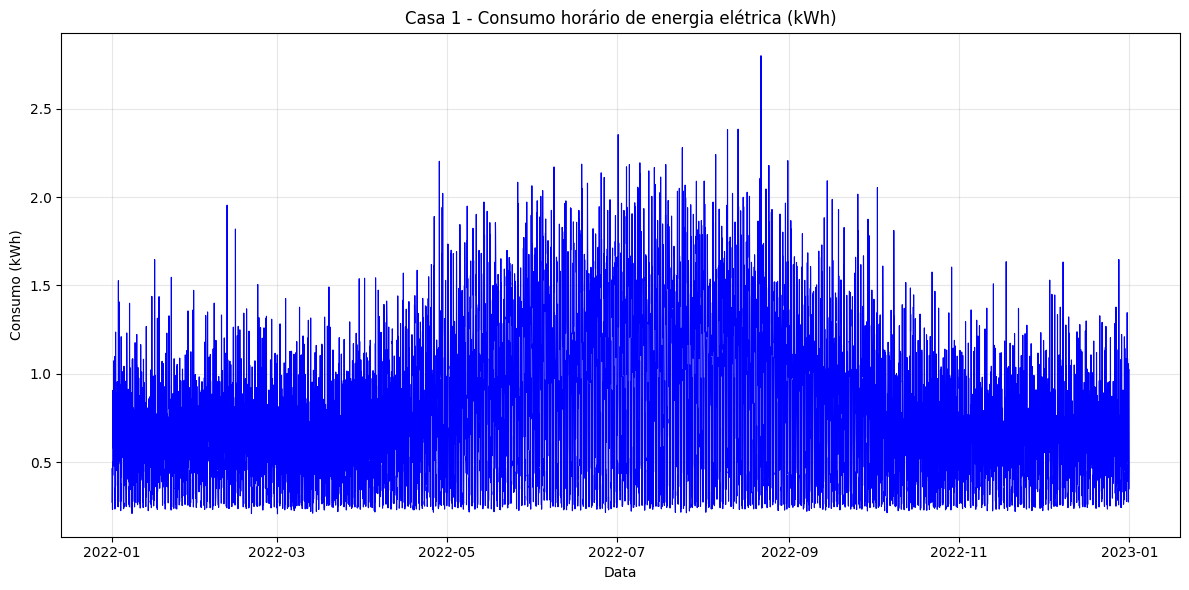

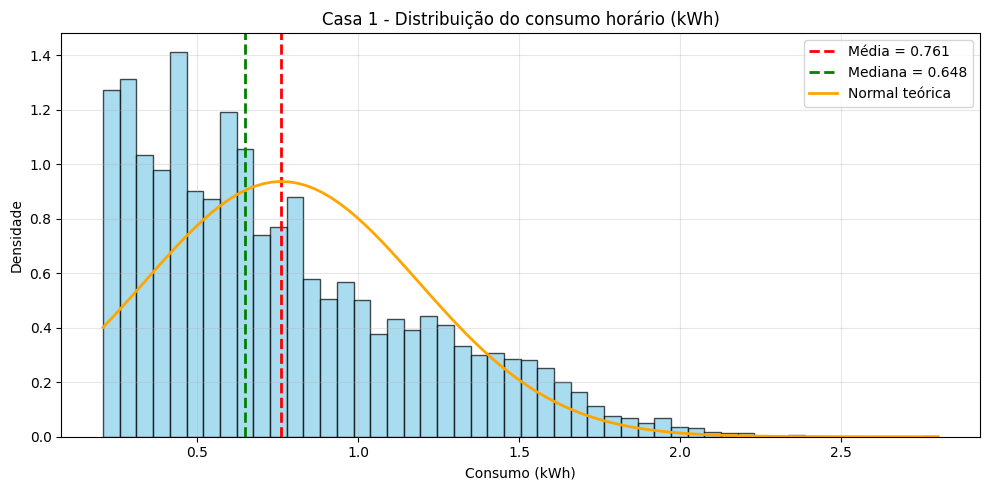

In [ ]:
HOME = 1

# Gráfico de série temporal
analyzer.plot_serie_temporal(home=HOME)

# Histograma com média, mediana e normal
analyzer.plot_histograma(home=HOME)

# # Boxplot comparativo
# analyzer.plot_boxplot()

# 5. Autocorrelação e Sazonalidade

## 5.1 O que são lags?

Em séries temporais, **lag** (defasagem) é o deslocamento temporal entre duas observações. Para uma série discreta $X_t$, um lag de $k$ compara o valor no instante $t$ com o valor no instante $t-k$ (passado) ou $t+k$ (futuro). A análise de lags permite investigar a memória e a periodicidade do processo.

- **Lag 1**: mede a dependência entre observações consecutivas (ex.: hora atual com a hora anterior).
- **Lag 24**: para dados horários, capta a repetição do padrão diário.

## 5.2 Função de Autocorrelação (ACF)

A ACF quantifica a correlação linear entre $X_t$ e $X_{t+k}$. Para um processo estacionário no sentido amplo (WSS), a ACF depende apenas do lag $k$:

$$
\rho(k) = \frac{\text{Cov}(X_t, X_{t+k})}{\text{Var}(X_t)} = \frac{\mathbb{E}[(X_t - \mu)(X_{t+k} - \mu)]}{\sigma^2}.
$$

**Propriedades importantes**:
- $\rho(0) = 1$ .
- Simetria: $\rho(k) = \rho(-k)$.
- $|\rho(k)| \leq 1$.
- Para processos sem componentes periódicas, $\rho(k) \to 0$ quando $k \to \infty$.


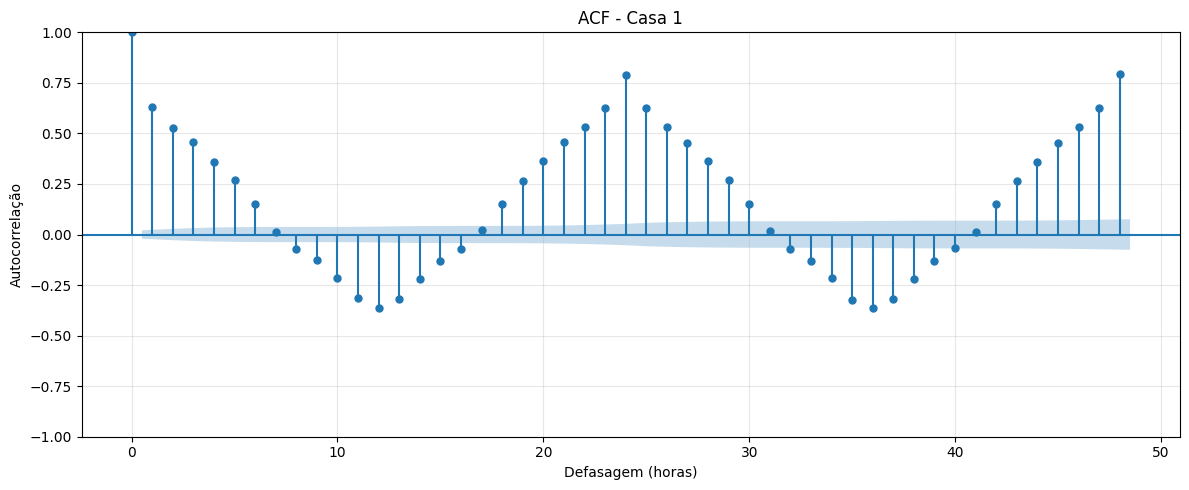

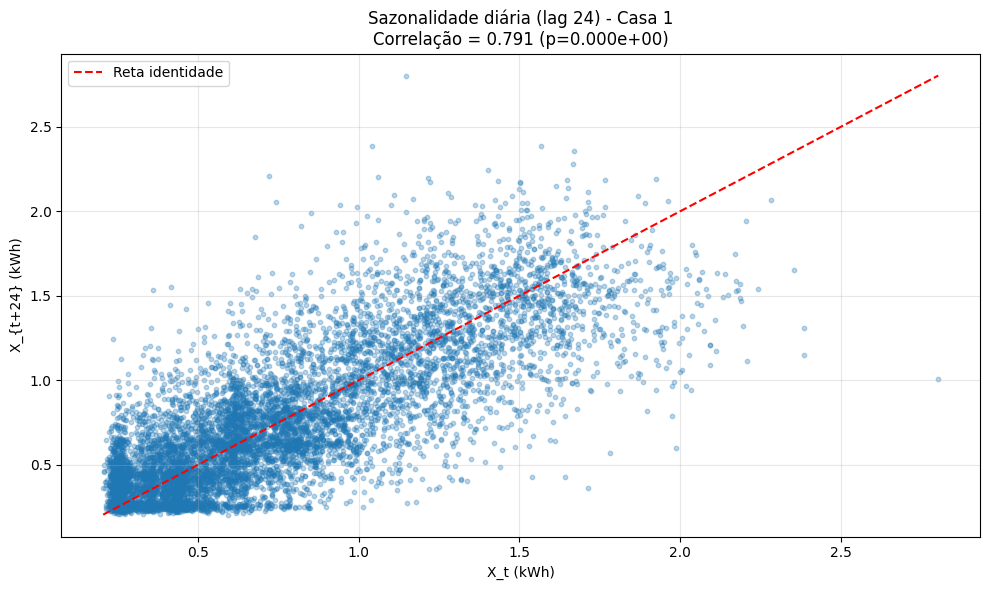

In [ ]:
# ACF para casa 1
analyzer.plot_acf(home=HOME)

# Dispersão lag 24
analyzer.plot_acf_scatter_lag24(home=HOME)

## 5.3 Interpretação dos Resultados

Os gráficos de ACF gerados para as séries de consumo horário mostram:

- **Lag 1**: $\rho(1)$ positivo e significativo – indica dependência serial imediata: o consumo em uma hora está correlacionado com o consumo da hora anterior.
- **Lag 24**: $\rho(24) \in [0.60, 0.79]$ – forte correlação entre o consumo de uma hora e o da mesma hora no dia seguinte. Isso é evidência clara de **sazonalidade diária**.
- **Picos em múltiplos de 24** (48, 72, …) reforçam a periodicidade diária.

## 5.4 Relação com a Estacionariedade

A presença de sazonalidade **determinística** (padrões fixos que se repetem) **não viola** a estacionariedade no sentido amplo. Em um processo WSS, a média é constante e a autocovariância depende apenas do lag. A sazonalidade determinística manifesta-se como picos na ACF nos lags correspondentes ao período, enquanto o decaimento geral da ACF para zero (após os picos) confirma a estacionariedade.

Por outro lado, se a sazonalidade for **estocástica**, o processo pode se tornar não estacionário. No nosso caso, a repetição diária é consistente e a média e variância se mantêm estáveis ao longo do ano, satisfazendo as condições de WSS.

Assim, a ACF serve tanto para identificar a estrutura de dependência temporal quanto para validar a hipótese de estacionariedade antes da modelagem.

# 6. Conclusão

Nesta análise, aplicamos conceitos fundamentais de processos estocásticos para avaliar a estacionariedade do consumo de energia elétrica de 10 residências. As principais conclusões são:

- As séries temporais são **estacionárias no sentido amplo** (média e variância constantes).
- Há forte **sazonalidade diária**, evidenciada pelas altas autocorrelações no lag 24.
- A distribuição do consumo é **assimétrica à direita** e, para a maioria das casas, **leptocúrtica** (caudas pesadas).
- Dois grupos de casas se destacam: **Grupo A (1 e 2)** com maior consumo médio e variabilidade, e **Grupo B (3 a 10)** com consumo menor e caudas mais pesadas.